# 02 . Term structure, 5-year ZCB and swap rate (Parts I b, I d)

$$Z(t,T) = A(t,T)\,e^{-B(t,T)\,r(t)},\qquad B(t,T) = \frac{1-e^{-a(T-t)}}{a},$$
$$A(t,T) = \exp\left[\left(b-\frac{\sigma^2}{2a^2}\right)\big(B(t,T)-(T-t)\big) - \frac{\sigma^2}{4a}B(t,T)^2\right].$$

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.float_format = "{:.6f}".format

In [2]:
from calibration import fetch_fed_rates, calibrate_vasicek
from vasicek import A, B, zcb_price, zero_rate, long_rate, term_structure
from swaps import vasicek_swap_rate, vasicek_discount, par_swap_rate, swap_value

r = fetch_fed_rates("DFF", start="2000-01-01")
fit = calibrate_vasicek(r)
a, b, sigma = fit["a"], fit["b"], fit["sigma"]
r_latest = fit["r_last"]
print(f"a = {a:.4f}, b = {b:.4%}, sigma = {sigma:.4%}, r(latest, {r.index[-1].date()}) = {r_latest:.4%}")

a = 0.1900, b = 2.0320%, sigma = 1.2397%, r(latest, 2026-10-01) = 3.8800%


## Part I(b): analytical price of the 5-year ZCB (face \$1)

In [3]:
t, T = 0.0, 5.0
rows = {}
for label, r0 in [("r(0) = latest DFF", r_latest), ("r(0) = 4%", 0.04)]:
    rows[label] = {"B(0,5)": B(t, T, a), "A(0,5)": A(t, T, a, b, sigma),
                   "Z(0,5)": zcb_price(r0, t, T, a, b, sigma),
                   "y(0,5)": zero_rate(r0, t, T, a, b, sigma)}
pd.DataFrame(rows).style.format("{:.6f}").format("{:.4%}", subset=pd.IndexSlice["y(0,5)", :])

,r(0) = latest DFF,r(0) = 4%
"B(0,5)",3.227896,3.227896
"A(0,5)",0.966239,0.966239
"Z(0,5)",0.852497,0.849201
"y(0,5)",3.1917%,3.2692%


In [4]:
ts = term_structure(0.04, [0.5, 1, 2, 3, 4, 5, 7, 10, 20, 30], a, b, sigma)
ts.style.format({"P(0,T)": "{:.6f}", "y(0,T)": "{:.4%}"})

,"P(0,T)","y(0,T)"
T,,
0.500000,0.980646,3.9088%
1.000000,0.962500,3.8221%
2.000000,0.929386,3.6615%
3.000000,0.899871,3.5168%
4.000000,0.873315,3.3865%
5.000000,0.849201,3.2692%
7.000000,0.806701,3.0686%
10.000000,0.753076,2.8359%
20.000000,0.617913,2.4070%


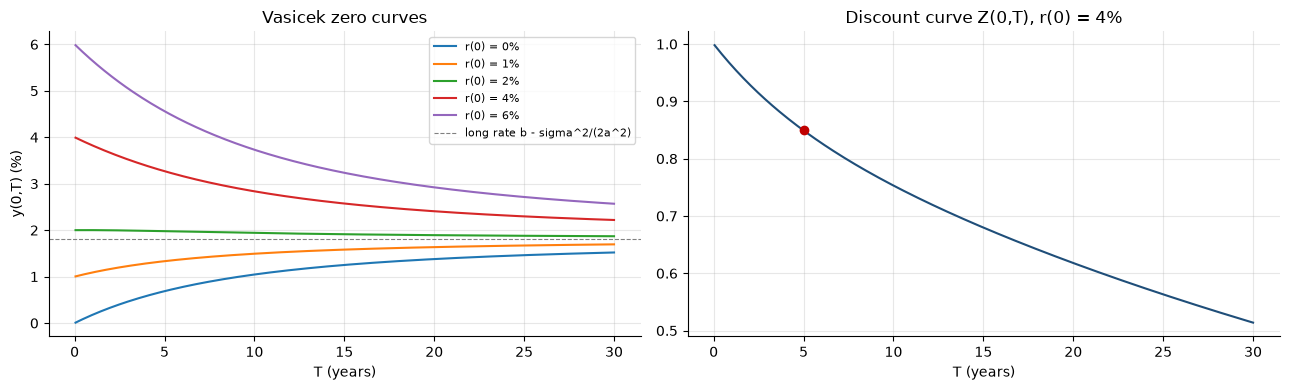

In [5]:
T_grid = np.linspace(0.05, 30, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for r0 in [0.0, 0.01, 0.02, 0.04, 0.06]:
    axes[0].plot(T_grid, zero_rate(r0, 0, T_grid, a, b, sigma) * 100, label=f"r(0) = {r0:.0%}")
axes[0].axhline(long_rate(a, b, sigma) * 100, color="grey", ls="--", lw=0.8,
                label="long rate b - sigma^2/(2a^2)")
axes[0].set_title("Vasicek zero curves"); axes[0].set_xlabel("T (years)"); axes[0].set_ylabel("y(0,T) (%)")
axes[0].legend(fontsize=8)
axes[1].plot(T_grid, zcb_price(0.04, 0, T_grid, a, b, sigma), color="#1f4e79")
axes[1].scatter([5], [zcb_price(0.04, 0, 5, a, b, sigma)], color="#c00000", zorder=3)
axes[1].set_title("Discount curve Z(0,T), r(0) = 4%"); axes[1].set_xlabel("T (years)")
plt.tight_layout(); plt.show()

The curve shape depends on $r(0)$ relative to $b$: above the long-run level it is inverted,
below it is upward sloping. $B(0,T)$ is the bond's sensitivity to the short rate,
$\partial \ln Z/\partial r = -B$.

## Part I(d): 5-year swap rate, annual payments

$$S = \frac{1 - Z(N)}{\sum_{i=1}^{N} Z(i)}$$

The floating leg on SOFR is worth $1 - Z(N)$ per unit notional (it reprices to par on each reset),
so $S$ is the fixed rate that makes the swap worth zero today.

In [6]:
res = vasicek_swap_rate(0.04, a, b, sigma, maturity=5, freq=1.0)
strip = pd.DataFrame({"Z(0,i)": res["Z"]}, index=pd.Index(res["times"].astype(int), name="i"))
display(strip.T)
print(f"sum Z(i)          = {res['sum_Z']:.6f}")
print(f"1 - Z(5)          = {1 - res['Z'][-1]:.6f}")
print(f"swap rate S       = {res['swap_rate']:.4%}")
disc = vasicek_discount(0.04, a, b, sigma)
print(f"swap value at S   = {swap_value(disc, res['swap_rate'], 5.0):.2e}  (zero by construction)")

i,1,2,3,4,5
"Z(0,i)",0.962500,0.929386,0.899871,0.873315,0.849201


sum Z(i)          = 4.514274
1 - Z(5)          = 0.150799
swap rate S       = 3.3405%
swap value at S   = 0.00e+00  (zero by construction)


In [7]:
mats = np.arange(1, 11)
swap_curve = pd.DataFrame({"par swap rate": [par_swap_rate(disc, m, 1.0) for m in mats],
                           "zero rate": zero_rate(0.04, 0, mats, a, b, sigma)},
                          index=pd.Index(mats, name="maturity (y)"))
swap_curve.style.format("{:.4%}")

,par swap rate,zero rate
maturity (y),,
1,3.8961%,3.8221%
2,3.7324%,3.6615%
3,3.5866%,3.5168%
4,3.4565%,3.3865%
5,3.3405%,3.2692%
6,3.2368%,3.1636%
7,3.1441%,3.0686%
8,3.0609%,2.9830%
9,2.9863%,2.9057%
